# 🌿 Clasificación de Enfermedades en Plantas — MobileNetV2 (Keras + .h5)

**Framework:** TensorFlow / Keras  
**Arquitectura:** MobileNetV2 (más ligera y rápida que ResNet50, ideal para móviles)  
**Modelo guardado:** `.h5` (compatible con Android via TFLite)

**Estructura del dataset:**
```
/kaggle/input/datasets/
├── saleidyma/background/Background_without_leaves/
└── abdallahalidev/plantvillage-dataset/segmented/
```

## 1. Verificar entorno y GPU

In [7]:
import tensorflow as tf

print(f'TensorFlow version : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU disponible     : {gpus}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('No se detectó GPU, se usará CPU (entrenamiento lento)')

2026-05-25 19:16:26.763213: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779736586.967215      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779736587.035451      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779736587.520752      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779736587.520790      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779736587.520793      57 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU disponible     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Importaciones

In [8]:
import os
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Importaciones listas ✓')

Importaciones listas ✓


## 3. Configuración de rutas e hiperparámetros

In [9]:
# ── Rutas ─────────────────────────────────────────────────────────────────────
INPUT_DIR        = Path('/kaggle/input/datasets')
OUTPUT_DIR       = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLANTVILLAGE_DIR = INPUT_DIR / 'abdallahalidev' / 'plantvillage-dataset' / 'segmented'
BACKGROUND_DIR   = INPUT_DIR / 'saleidyma' / 'background' / 'Background_without_leaves'
DATA_DIR         = OUTPUT_DIR / 'dataset_unificado'

# ── Hiperparámetros ───────────────────────────────────────────────────────────
IMG_SIZE       = 224       # MobileNetV2 usa 224x224
BATCH_SIZE     = 32
NUM_EPOCHS     = 50
LR             = 1e-4
ES_PATIENCE    = 10        # Early Stopping
LR_PATIENCE    = 5         # ReduceLROnPlateau
UNFREEZE_EPOCH = 10        # Epoca para iniciar fine-tune

VAL_SPLIT  = 0.15
TEST_SPLIT = 0.10

# ── Rutas de salida ───────────────────────────────────────────────────────────
BEST_MODEL_PATH  = str(OUTPUT_DIR / 'mobilenet_best_model.h5')
FINAL_MODEL_PATH = str(OUTPUT_DIR / 'mobilenet_final_model.h5')
CLASS_NAMES_PATH = OUTPUT_DIR / 'class_names.json'

print('Configuracion cargada ✓')
print(f'  PlantVillage : {PLANTVILLAGE_DIR}')
print(f'  Background   : {BACKGROUND_DIR}')
print(f'  Output       : {OUTPUT_DIR}')

Configuracion cargada ✓
  PlantVillage : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented
  Background   : /kaggle/input/datasets/saleidyma/background/Background_without_leaves
  Output       : /kaggle/working


## 4. Construcción del dataset unificado

In [10]:
def build_unified_dataset(plantvillage_dir, background_dir, output_dir,
                           background_class_name='Background'):
    unified = output_dir / 'all_classes'

    if unified.exists():
        print(f'Dataset unificado ya existe en {unified}')
        return unified

    unified.mkdir(parents=True)
    copied = 0

    # ── PlantVillage ──────────────────────────────────────────────────────────
    if not plantvillage_dir.exists():
        raise FileNotFoundError(f'No se encontro PlantVillage en: {plantvillage_dir}')

    for class_folder in sorted(plantvillage_dir.iterdir()):
        if not class_folder.is_dir():
            continue
        dest = unified / class_folder.name
        dest.mkdir(exist_ok=True)
        for img in class_folder.iterdir():
            if img.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
                shutil.copy2(str(img), str(dest / img.name))
                copied += 1

    # ── Background ───────────────────────────────────────────────────────────
    if not background_dir.exists():
        raise FileNotFoundError(f'No se encontro Background en: {background_dir}')

    bg_dest = unified / background_class_name
    bg_dest.mkdir(exist_ok=True)
    for img in background_dir.rglob('*'):
        if img.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
            shutil.copy2(str(img), str(bg_dest / img.name))
            copied += 1

    print(f'Dataset unificado creado en: {unified}')
    print(f'  Clases    : {len(list(unified.iterdir()))}')
    print(f'  Imagenes  : {copied:,}')
    return unified


# Limpiar si existe dataset vacio de intento anterior
prev = DATA_DIR / 'all_classes'
if prev.exists():
    total_imgs = sum(1 for f in prev.rglob('*') if f.is_file())
    if total_imgs == 0:
        shutil.rmtree(DATA_DIR)
        print('Carpeta vacia eliminada, reconstruyendo...')

UNIFIED_DIR = build_unified_dataset(PLANTVILLAGE_DIR, BACKGROUND_DIR, DATA_DIR)

Dataset unificado creado en: /kaggle/working/dataset_unificado/all_classes
  Clases    : 39
  Imagenes  : 55,449


## 5. Exploración del dataset

Total clases  : 39
Total imagenes: 55,449


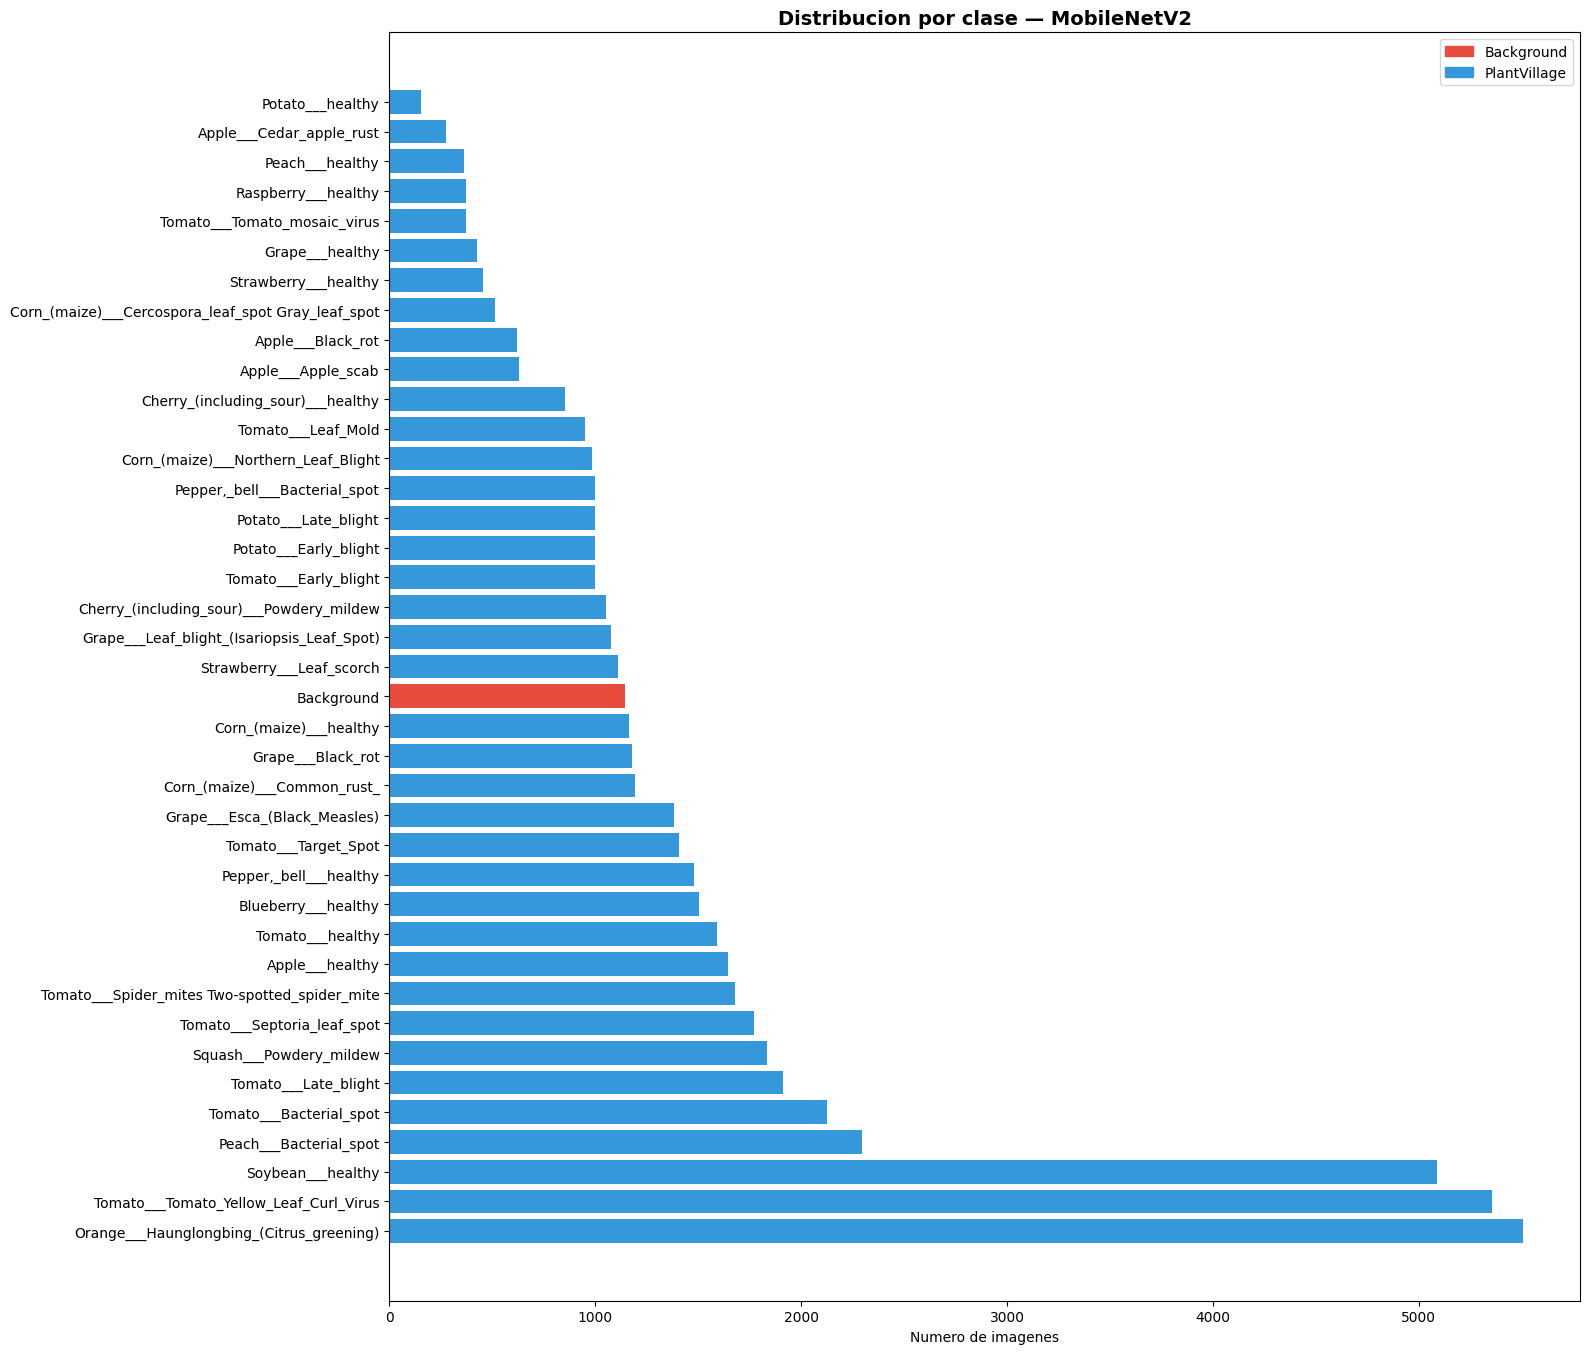

                                             Clase  Cantidad
          Orange___Haunglongbing_(Citrus_greening)      5507
            Tomato___Tomato_Yellow_Leaf_Curl_Virus      5357
                                 Soybean___healthy      5090
                            Peach___Bacterial_spot      2297
                           Tomato___Bacterial_spot      2127
                              Tomato___Late_blight      1909
                           Squash___Powdery_mildew      1835
                       Tomato___Septoria_leaf_spot      1771
     Tomato___Spider_mites Two-spotted_spider_mite      1676
                                   Apple___healthy      1645
                                  Tomato___healthy      1591
                               Blueberry___healthy      1502
                            Pepper,_bell___healthy      1478
                              Tomato___Target_Spot      1404
                      Grape___Esca_(Black_Measles)      1384
                       C

In [11]:
class_counts = {}
for class_dir in sorted(UNIFIED_DIR.iterdir()):
    if class_dir.is_dir():
        imgs = [f for f in class_dir.iterdir()
                if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}]
        class_counts[class_dir.name] = len(imgs)

total = sum(class_counts.values())
print(f'Total clases  : {len(class_counts)}')
print(f'Total imagenes: {total:,}')

df_counts = pd.DataFrame(
    list(class_counts.items()), columns=['Clase', 'Cantidad']
).sort_values('Cantidad', ascending=False)

fig, ax = plt.subplots(figsize=(16, max(6, len(class_counts) * 0.35)))
colors = ['#e74c3c' if 'Background' in c else '#3498db' for c in df_counts['Clase']]
ax.barh(df_counts['Clase'], df_counts['Cantidad'], color=colors)
ax.set_xlabel('Numero de imagenes')
ax.set_title('Distribucion por clase — MobileNetV2', fontsize=14, fontweight='bold')
bg_patch = mpatches.Patch(color='#e74c3c', label='Background')
pv_patch = mpatches.Patch(color='#3498db', label='PlantVillage')
ax.legend(handles=[bg_patch, pv_patch])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=120)
plt.show()
print(df_counts.to_string(index=False))

## 6. División del dataset y generadores de datos

In [12]:
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

def split_dataset(unified_dir, train_dir, val_dir, test_dir,
                  val_split=0.15, test_split=0.10, seed=42):
    if train_dir.exists():
        print('Split ya existe, omitiendo...')
        return

    random.seed(seed)
    for split_dir in [train_dir, val_dir, test_dir]:
        split_dir.mkdir(parents=True, exist_ok=True)

    total_copied = 0
    for class_dir in sorted(unified_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        imgs = [f for f in class_dir.iterdir()
                if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}]
        random.shuffle(imgs)

        n_test = max(1, int(len(imgs) * test_split))
        n_val  = max(1, int(len(imgs) * val_split))

        splits = {
            test_dir : imgs[:n_test],
            val_dir  : imgs[n_test:n_test + n_val],
            train_dir: imgs[n_test + n_val:]
        }

        for dest_dir, files in splits.items():
            cls_dest = dest_dir / class_dir.name
            cls_dest.mkdir(exist_ok=True)
            for f in files:
                shutil.copy2(str(f), str(cls_dest / f.name))
                total_copied += 1

    print(f'Split completado: {total_copied:,} imagenes distribuidas')
    for name, d in [('Train', train_dir), ('Val', val_dir), ('Test', test_dir)]:
        n = sum(1 for f in d.rglob('*') if f.is_file())
        print(f'  {name}: {n:,}')


split_dataset(UNIFIED_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR,
              val_split=VAL_SPLIT, test_split=TEST_SPLIT)

# ── ImageDataGenerators ───────────────────────────────────────────────────────
# MobileNetV2 requiere preprocesamiento en rango [-1, 1] via preprocess_input
# Se aplica como funcion de preprocesamiento personalizada

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

with open(CLASS_NAMES_PATH, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

print(f'Clases detectadas : {NUM_CLASSES}')
print(f'Clases guardadas en: {CLASS_NAMES_PATH}')

Split completado: 55,449 imagenes distribuidas
  Train: 41,618
  Val: 8,300
  Test: 5,531
Found 41618 images belonging to 39 classes.
Found 8300 images belonging to 39 classes.
Found 5531 images belonging to 39 classes.
Clases detectadas : 39
Clases guardadas en: /kaggle/working/class_names.json


## 7. Construcción del modelo MobileNetV2

In [13]:
def build_mobilenetv2(num_classes, input_shape=(224, 224, 3), freeze_backbone=True):
    """
    MobileNetV2 preentrenado en ImageNet con cabeza personalizada.
    Fase 1: solo se entrena la cabeza (backbone congelada)
    Fase 2: fine-tune de las capas superiores

    Ventajas de MobileNetV2 vs ResNet50:
      - ~3.4M parametros vs ~25M (ResNet50)
      - Mucho mas rapido en inferencia
      - Modelo .tflite significativamente mas pequeno
      - Ideal para dispositivos moviles
    """
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = not freeze_backbone

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model


model, base_model = build_mobilenetv2(NUM_CLASSES, freeze_backbone=True)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Parametros totales     : {model.count_params():,}')
print(f'Parametros entrenables : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')
model.summary()

I0000 00:00:1779736998.407749      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779736998.413724      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parametros totales     : 3,058,279
Parametros entrenables : 798,759


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 39)             │        10,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,058,279 (11.67 MB)

 Trainable params: 798,759 (3.05 MB)

 Non-trainable params: 2,259,520 (8.62 MB)

## 8. Callbacks

In [14]:
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

early_stopping_cb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=ES_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=LR_PATIENCE,
    min_lr=1e-7,
    verbose=1
)

csv_logger_cb = callbacks.CSVLogger(
    str(OUTPUT_DIR / 'training_log.csv'), append=False
)

callbacks_phase1 = [checkpoint_cb, early_stopping_cb, reduce_lr_cb, csv_logger_cb]

print('Callbacks configurados:')
print('  ModelCheckpoint   → guarda mejor modelo como .h5')
print('  EarlyStopping     → detiene si no mejora en', ES_PATIENCE, 'epocas')
print('  ReduceLROnPlateau → reduce LR si no mejora en', LR_PATIENCE, 'epocas')
print('  CSVLogger         → registra historial en training_log.csv')

Callbacks configurados:
  ModelCheckpoint   → guarda mejor modelo como .h5
  EarlyStopping     → detiene si no mejora en 10 epocas
  ReduceLROnPlateau → reduce LR si no mejora en 5 epocas
  CSVLogger         → registra historial en training_log.csv


## 9. Entrenamiento — Fase 1 (cabeza)

In [15]:
print('=' * 60)
print('FASE 1: Entrenando solo la cabeza (backbone congelada)')
print('=' * 60)

history1 = model.fit(
    train_gen,
    epochs=UNFREEZE_EPOCH,
    validation_data=val_gen,
    callbacks=callbacks_phase1
)

print(f'\nFase 1 completada.')
print(f'Mejor val_loss hasta ahora: {min(history1.history["val_loss"]):.4f}')

FASE 1: Entrenando solo la cabeza (backbone congelada)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1779737007.523200     199 service.cc:152] XLA service 0x7acff0115a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779737007.523254     199 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779737007.523261     199 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779737008.719838     199 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-25 19:23:37.841269: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-25 19:23:37.979264: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1779737020.967952     199 device_co

 662/1301 ━━━━━━━━━━━━━━━━━━━━ 4:02 379ms/step - accuracy: 0.3562 - loss: 2.6070

...

1301/1301 ━━━━━━━━━━━━━━━━━━━━ 495s 380ms/step - accuracy: 0.8728 - loss: 0.4147 - val_accuracy: 0.9302 - val_loss: 0.2191 - learning_rate: 1.0000e-04
Epoch 6/10
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8831 - loss: 0.3736
Epoch 6: val_loss improved from 0.21907 to 0.19697, saving model to /kaggle/working/mobilenet_best_model.h5


1301/1301 ━━━━━━━━━━━━━━━━━━━━ 494s 379ms/step - accuracy: 0.8831 - loss: 0.3736 - val_accuracy: 0.9361 - val_loss: 0.1970 - learning_rate: 1.0000e-04
Epoch 7/10
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8861 - loss: 0.3510
Epoch 7: val_loss improved from 0.19697 to 0.18867, saving model to /kaggle/working/mobilenet_best_model.h5


1301/1301 ━━━━━━━━━━━━━━━━━━━━ 490s 376ms/step - accuracy: 0.8861 - loss: 0.3510 - val_accuracy: 0.9373 - val_loss: 0.1887 - learning_rate: 1.0000e-04
Epoch 8/10
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8901 - loss: 0.3423
Epoch 8: val_loss improved from 0.18867 to 0.18607, saving model to /kaggle/working/mobilenet_best_model.h5


1301/1301 ━━━━━━━━━━━━━━━━━━━━ 491s 377ms/step - accuracy: 0.8901 - loss: 0.3423 - val_accuracy: 0.9384 - val_loss: 0.1861 - learning_rate: 1.0000e-04
Epoch 9/10
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8963 - loss: 0.3249
Epoch 9: val_loss improved from 0.18607 to 0.17425, saving model to /kaggle/working/mobilenet_best_model.h5


1301/1301 ━━━━━━━━━━━━━━━━━━━━ 494s 380ms/step - accuracy: 0.8963 - loss: 0.3249 - val_accuracy: 0.9410 - val_loss: 0.1742 - learning_rate: 1.0000e-04
Epoch 10/10
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9015 - loss: 0.3097
Epoch 10: val_loss did not improve from 0.17425
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 493s 379ms/step - accuracy: 0.9015 - loss: 0.3097 - val_accuracy: 0.9407 - val_loss: 0.1769 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 9.

Fase 1 completada.
Mejor val_loss hasta ahora: 0.1742


## 10. Entrenamiento — Fase 2 (fine-tune)

In [16]:
print('=' * 60)
print('FASE 2: Fine-tune (descongelando capas superiores de MobileNetV2)')
print('=' * 60)

# MobileNetV2 tiene ~154 capas; congelamos las primeras 100
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Parametros entrenables en fase 2: {trainable_count:,}')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR / 10),  # LR 10x menor
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb2 = callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

early_stopping_cb2 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=ES_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb2 = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=LR_PATIENCE,
    min_lr=1e-8,
    verbose=1
)

csv_logger_cb2 = callbacks.CSVLogger(
    str(OUTPUT_DIR / 'training_log.csv'), append=True
)

history2 = model.fit(
    train_gen,
    epochs=NUM_EPOCHS - UNFREEZE_EPOCH,
    validation_data=val_gen,
    callbacks=[checkpoint_cb2, early_stopping_cb2, reduce_lr_cb2, csv_logger_cb2]
)

print(f'\nFase 2 completada.')
print(f'Mejor val_loss: {min(history2.history["val_loss"]):.4f}')

FASE 2: Fine-tune (descongelando capas superiores de MobileNetV2)
Parametros entrenables en fase 2: 2,660,199
Epoch 1/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.7707 - loss: 0.7576
Epoch 1: val_loss improved from inf to 0.20859, saving model to /kaggle/working/mobilenet_best_model.h5


1301/1301 ━━━━━━━━━━━━━━━━━━━━ 537s 395ms/step - accuracy: 0.7707 - loss: 0.7575 - val_accuracy: 0.9295 - val_loss: 0.2086 - learning_rate: 1.0000e-05
Epoch 2/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8747 - loss: 0.3937
Epoch 2: val_loss improved from 0.20859 to 0.16502, saving model to /kaggle/working/mobilenet_best_model.h5


1301/1301 ━━━━━━━━━━━━━━━━━━━━ 497s 382ms/step - accuracy: 0.8747 - loss: 0.3937 - val_accuracy: 0.9439 - val_loss: 0.1650 - learning_rate: 1.0000e-05
Epoch 3/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8959 - loss: 0.3173
Epoch 3: val_loss improved from 0.16502 to 0.15306, saving model to /kaggle/working/mobilenet_best_model.h5


1301/1301 ━━━━━━━━━━━━━━━━━━━━ 496s 381ms/step - accuracy: 0.8959 - loss: 0.3173 - val_accuracy: 0.9481 - val_loss: 0.1531 - learning_rate: 1.0000e-05
Epoch 4/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9135 - loss: 0.2714
Epoch 4: val_loss improved from 0.15306 to 0.14357, saving model to /kaggle/working/mobilenet_best_model.h5


1301/1301 ━━━━━━━━━━━━━━━━━━━━ 497s 382ms/step - accuracy: 0.9136 - loss: 0.2714 - val_accuracy: 0.9506 - val_loss: 0.1436 - learning_rate: 1.0000e-05
Epoch 5/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9250 - loss: 0.2347
Epoch 5: val_loss improved from 0.14357 to 0.13066, saving model to /kaggle/working/mobilenet_best_model.h5


...

1301/1301 ━━━━━━━━━━━━━━━━━━━━ 497s 382ms/step - accuracy: 0.9708 - loss: 0.0901 - val_accuracy: 0.9808 - val_loss: 0.0604 - learning_rate: 1.0000e-05
Epoch 21/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9749 - loss: 0.0830
Epoch 21: val_loss did not improve from 0.06044
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 509s 391ms/step - accuracy: 0.9749 - loss: 0.0830 - val_accuracy: 0.9776 - val_loss: 0.0653 - learning_rate: 1.0000e-05
Epoch 22/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9718 - loss: 0.0865
Epoch 22: val_loss did not improve from 0.06044
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 498s 383ms/step - accuracy: 0.9718 - loss: 0.0865 - val_accuracy: 0.9780 - val_loss: 0.0646 - learning_rate: 1.0000e-05
Epoch 23/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9747 - loss: 0.0798
Epoch 23: val_loss did not improve from 0.06044
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 496s 381ms/step - accuracy: 0.9747 - loss: 0.0798 - val_accuracy: 0.9766 - val_loss: 0.0677 - learn

1301/1301 ━━━━━━━━━━━━━━━━━━━━ 498s 383ms/step - accuracy: 0.9778 - loss: 0.0702 - val_accuracy: 0.9795 - val_loss: 0.0596 - learning_rate: 5.0000e-06
Epoch 27/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9766 - loss: 0.0728
Epoch 27: val_loss improved from 0.05963 to 0.05720, saving model to /kaggle/working/mobilenet_best_model.h5


1301/1301 ━━━━━━━━━━━━━━━━━━━━ 498s 383ms/step - accuracy: 0.9766 - loss: 0.0728 - val_accuracy: 0.9799 - val_loss: 0.0572 - learning_rate: 5.0000e-06
Epoch 28/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9790 - loss: 0.0671
Epoch 28: val_loss improved from 0.05720 to 0.05164, saving model to /kaggle/working/mobilenet_best_model.h5


1301/1301 ━━━━━━━━━━━━━━━━━━━━ 496s 381ms/step - accuracy: 0.9790 - loss: 0.0671 - val_accuracy: 0.9823 - val_loss: 0.0516 - learning_rate: 5.0000e-06
Epoch 29/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9797 - loss: 0.0647
Epoch 29: val_loss did not improve from 0.05164
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 494s 380ms/step - accuracy: 0.9797 - loss: 0.0647 - val_accuracy: 0.9818 - val_loss: 0.0558 - learning_rate: 5.0000e-06
Epoch 30/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9792 - loss: 0.0661
Epoch 30: val_loss did not improve from 0.05164
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 502s 386ms/step - accuracy: 0.9792 - loss: 0.0661 - val_accuracy: 0.9811 - val_loss: 0.0550 - learning_rate: 5.0000e-06
Epoch 31/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9800 - loss: 0.0655
Epoch 31: val_loss did not improve from 0.05164
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 497s 382ms/step - accuracy: 0.9800 - loss: 0.0655 - val_accuracy: 0.9829 - val_loss: 0.0523 - learn

1301/1301 ━━━━━━━━━━━━━━━━━━━━ 502s 386ms/step - accuracy: 0.9813 - loss: 0.0613 - val_accuracy: 0.9828 - val_loss: 0.0512 - learning_rate: 5.0000e-06
Epoch 33/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9808 - loss: 0.0625
Epoch 33: val_loss did not improve from 0.05124
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 500s 385ms/step - accuracy: 0.9808 - loss: 0.0625 - val_accuracy: 0.9793 - val_loss: 0.0588 - learning_rate: 5.0000e-06
Epoch 34/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9814 - loss: 0.0597
Epoch 34: val_loss did not improve from 0.05124
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 492s 378ms/step - accuracy: 0.9814 - loss: 0.0598 - val_accuracy: 0.9798 - val_loss: 0.0595 - learning_rate: 5.0000e-06
Epoch 35/40
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9816 - loss: 0.0578
Epoch 35: val_loss did not improve from 0.05124
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 497s 382ms/step - accuracy: 0.9816 - loss: 0.0578 - val_accuracy: 0.9820 - val_loss: 0.0555 - learn

## 11. Curvas de aprendizaje

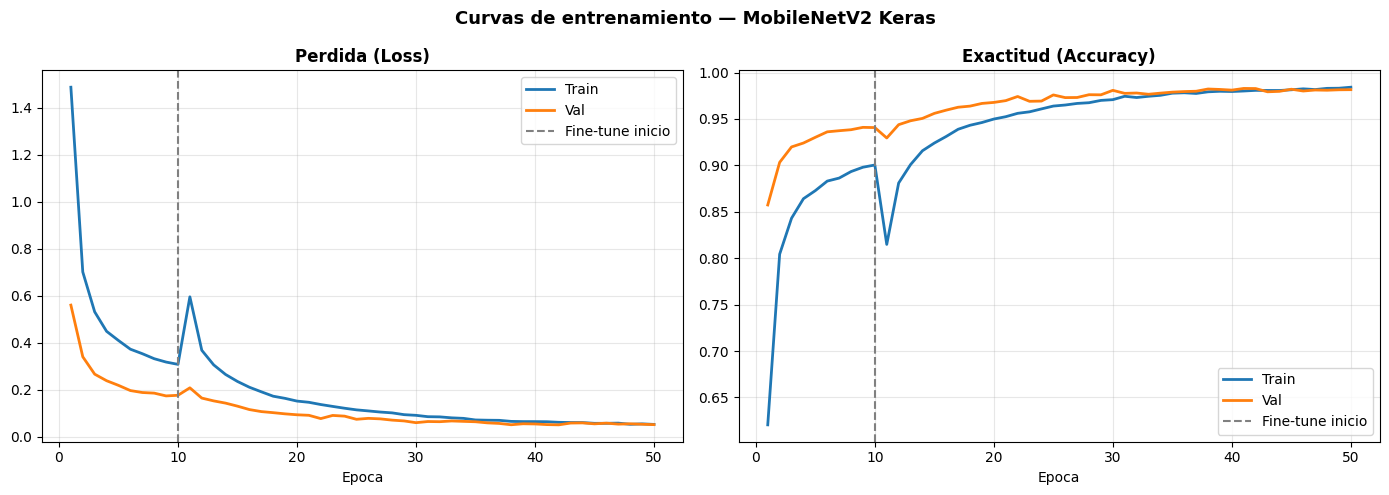

In [24]:
train_loss = history1.history['loss'] + history2.history['loss']
val_loss   = history1.history['val_loss'] + history2.history['val_loss']
train_acc  = history1.history['accuracy'] + history2.history['accuracy']
val_acc    = history1.history['val_accuracy'] + history2.history['val_accuracy']
epochs_ran = list(range(1, len(train_loss) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, train_loss, label='Train', linewidth=2)
axes[0].plot(epochs_ran, val_loss,   label='Val',   linewidth=2)
axes[0].axvline(x=UNFREEZE_EPOCH, color='gray', linestyle='--', label='Fine-tune inicio')
axes[0].set_title('Perdida (Loss)', fontweight='bold')
axes[0].set_xlabel('Epoca')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, train_acc, label='Train', linewidth=2)
axes[1].plot(epochs_ran, val_acc,   label='Val',   linewidth=2)
axes[1].axvline(x=UNFREEZE_EPOCH, color='gray', linestyle='--', label='Fine-tune inicio')
axes[1].set_title('Exactitud (Accuracy)', fontweight='bold')
axes[1].set_xlabel('Epoca')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de entrenamiento — MobileNetV2 Keras', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'learning_curves.png', dpi=120)
plt.show()

## 12. Evaluación en Test Set

In [25]:
best_model = keras.models.load_model(BEST_MODEL_PATH)
print(f'Mejor modelo cargado desde: {BEST_MODEL_PATH}')

test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

test_gen.reset()
preds = best_model.predict(test_gen, verbose=1)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_gen.classes

print('\nReporte de clasificacion:')
print(classification_report(true_classes, pred_classes,
                             target_names=CLASS_NAMES, digits=4))

Mejor modelo cargado desde: /kaggle/working/mobilenet_best_model.h5
173/173 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.9846 - loss: 0.0511

Test Loss     : 0.0645
Test Accuracy : 0.9796 (97.96%)
173/173 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step

Reporte de clasificacion:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9841    0.9920        63
                                 Apple___Black_rot     0.9841    1.0000    0.9920        62
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        27
                                   Apple___healthy     0.9704    1.0000    0.9850       164
                                        Background     0.9913    1.0000    0.9956       114
                               Blueberry___healthy     1.0000    0.9933    0.9967       150
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9810    0.9904   

## 13. Matriz de confusión

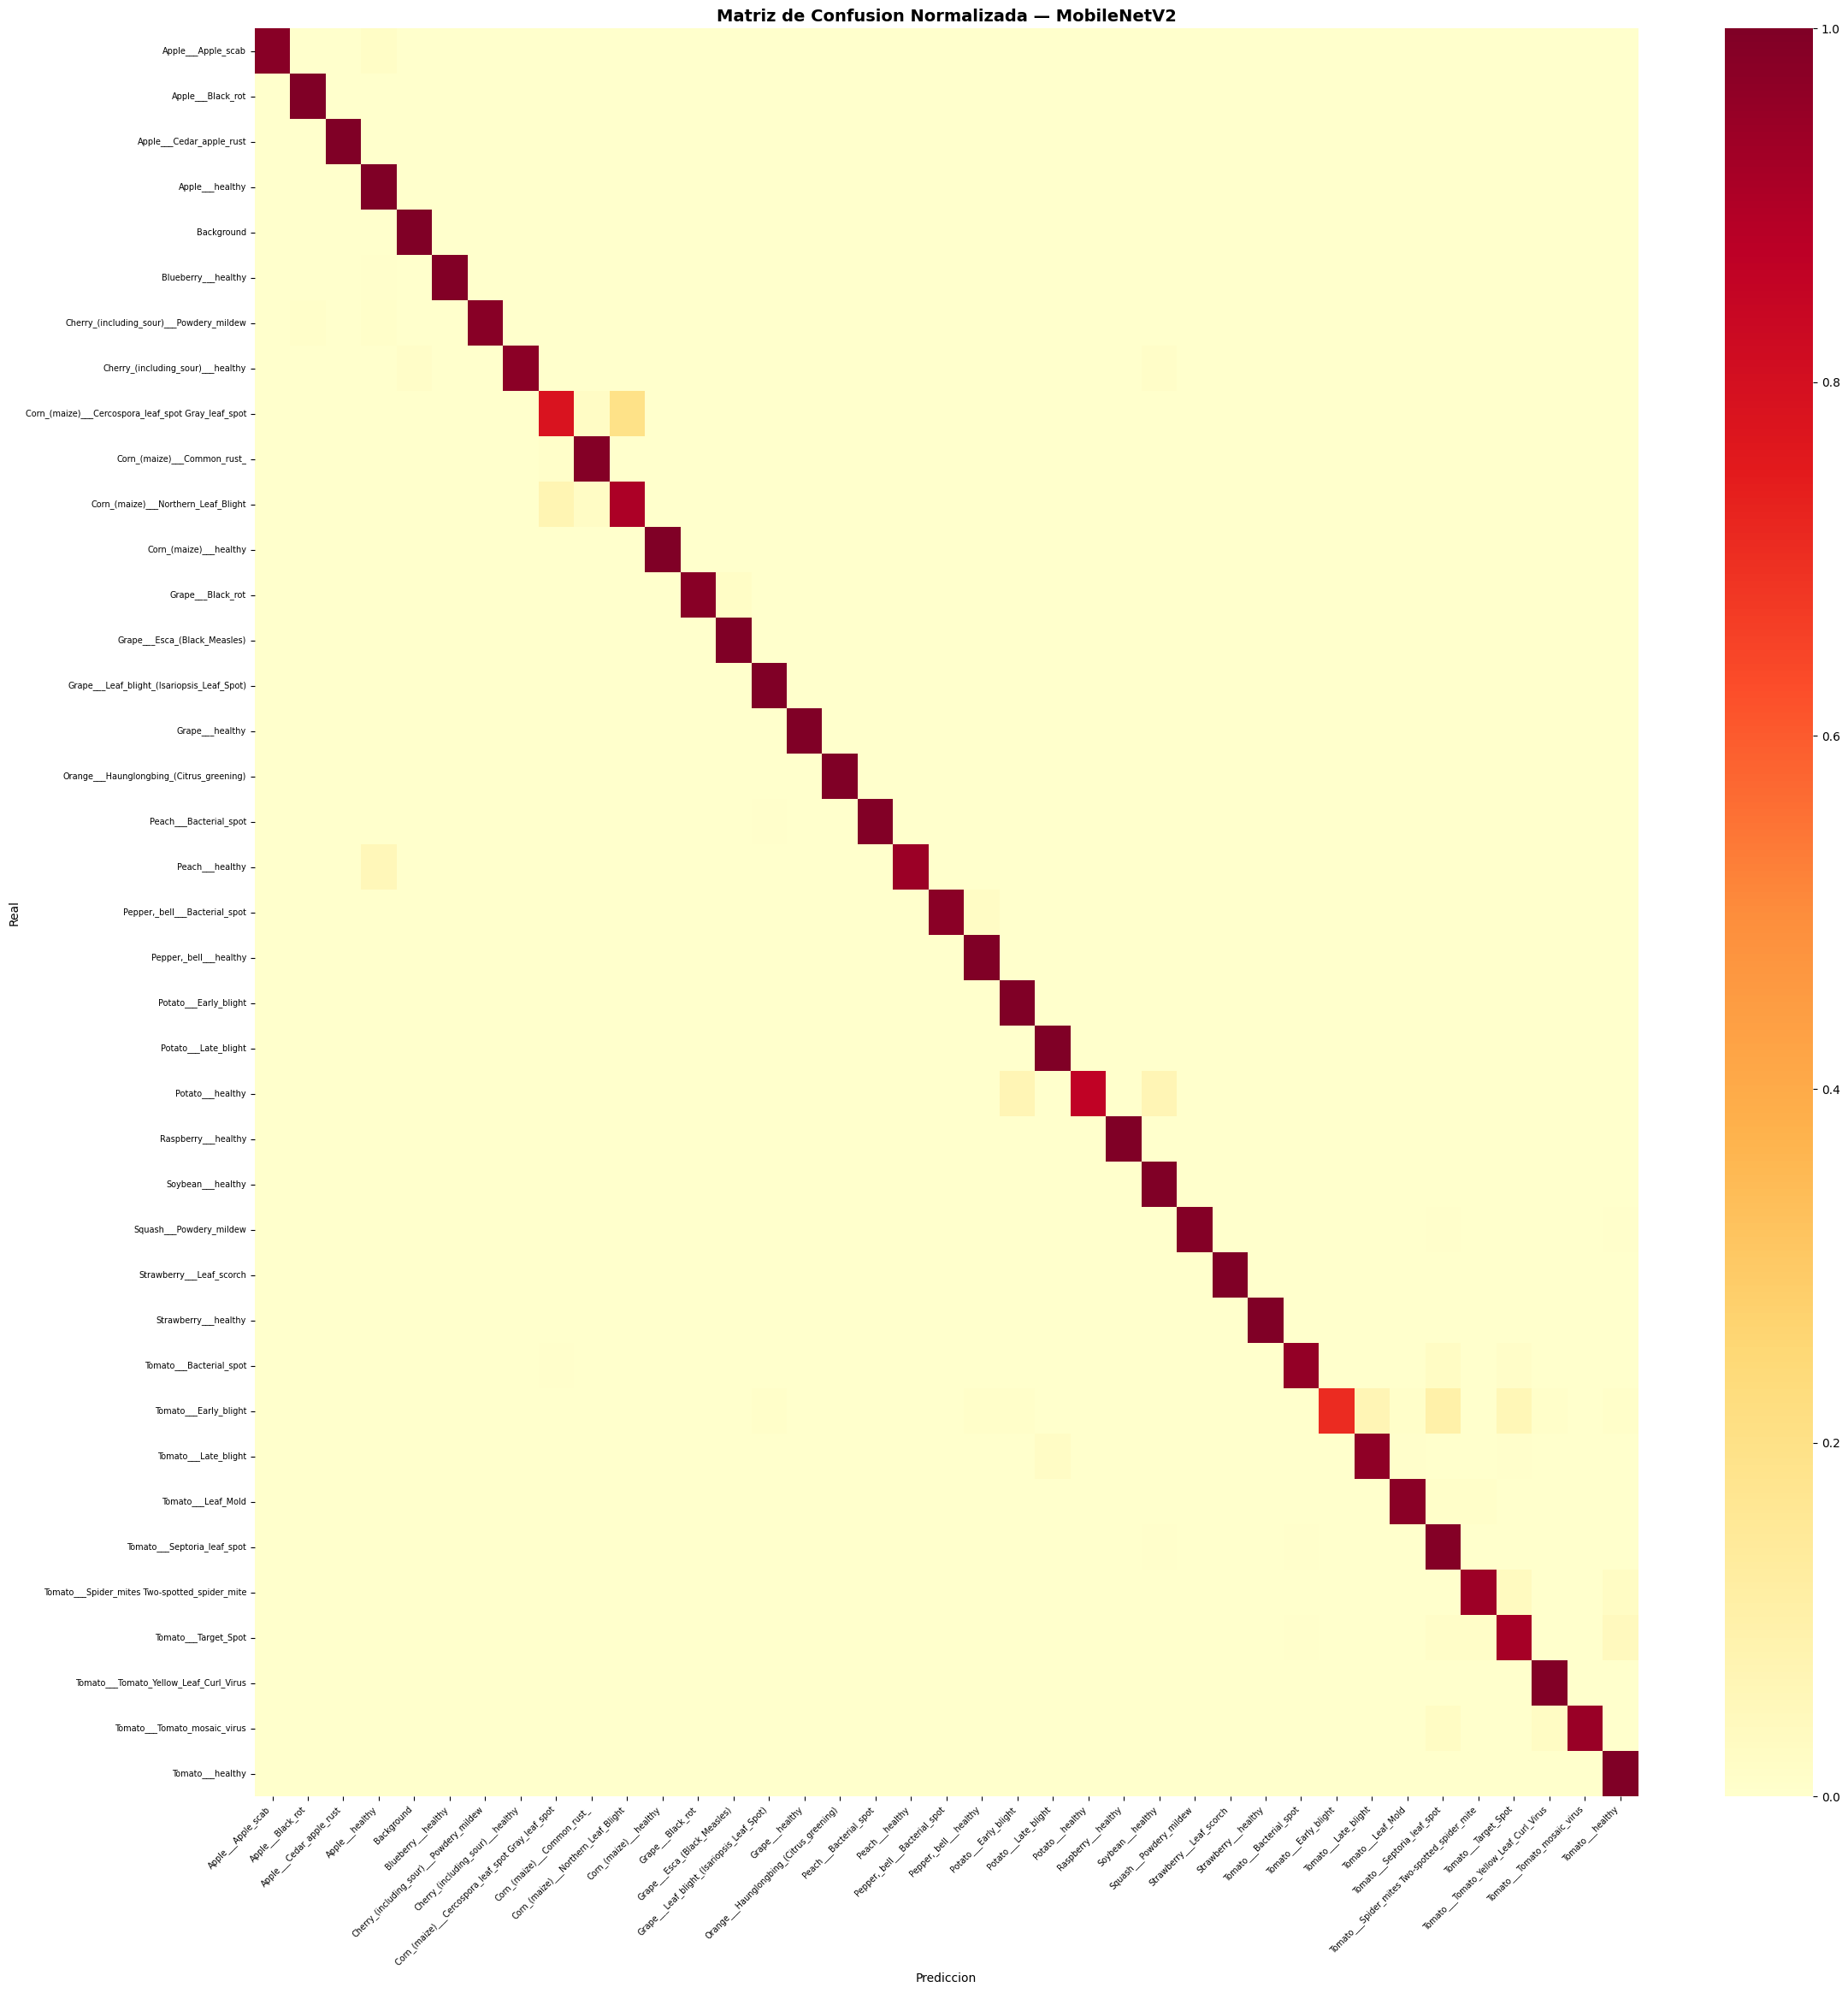

Background recall    : 1.0000
Plantas como fondo   : 1


In [28]:
cm = confusion_matrix(true_classes, pred_classes)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig_size = max(16, NUM_CLASSES * 0.6)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))
sns.heatmap(cm_norm, annot=NUM_CLASSES <= 30, fmt='.2f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='YlOrRd', ax=ax)
ax.set_title('Matriz de Confusion Normalizada — MobileNetV2', fontsize=14, fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Prediccion')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

if 'Background' in CLASS_NAMES:
    bg_idx  = CLASS_NAMES.index('Background')
    bg_mask = true_classes == bg_idx
    bg_acc  = (pred_classes[bg_mask] == bg_idx).mean() if bg_mask.any() else 0
    false_bg = ((true_classes != bg_idx) & (pred_classes == bg_idx)).sum()
    print(f'Background recall    : {bg_acc:.4f}')
    print(f'Plantas como fondo   : {false_bg}')

## 14. Guardar modelo final y exportar a TFLite

In [29]:
# ── Guardar modelo final en .h5 ───────────────────────────────────────────────
best_model.save(FINAL_MODEL_PATH)
print(f'Modelo final guardado  : {FINAL_MODEL_PATH}')
print(f'Mejor modelo guardado  : {BEST_MODEL_PATH}')

# ── Exportar a TFLite (para Android) ─────────────────────────────────────────
# MobileNetV2 produce un .tflite mucho mas pequeno que ResNet50
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # cuantizacion automatica
tflite_model = converter.convert()

tflite_path = OUTPUT_DIR / 'mobilenet_android.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

h5_size     = os.path.getsize(BEST_MODEL_PATH) / 1e6
tflite_size = os.path.getsize(tflite_path) / 1e6
print(f'\nArchivos generados:')
print(f'  mobilenet_best_model.h5   : {h5_size:.1f} MB')
print(f'  mobilenet_android.tflite  : {tflite_size:.1f} MB  ← usar en Android')
print(f'  class_names.json          : lista de clases')
print(f'  learning_curves.png       : curvas de entrenamiento')
print(f'  confusion_matrix.png      : matriz de confusion')

Modelo final guardado  : /kaggle/working/mobilenet_final_model.h5
Mejor modelo guardado  : /kaggle/working/mobilenet_best_model.h5
INFO:tensorflow:Assets written to: /tmp/tmpawe2pcou/assets


INFO:tensorflow:Assets written to: /tmp/tmpawe2pcou/assets


Saved artifact at '/tmp/tmpawe2pcou'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 39), dtype=tf.float32, name=None)
Captures:
  135034984518800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135033242793168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135033242792976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034984519568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034984520144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135033242793552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135033242790288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135033242789328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135033242791440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135033242794512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135033242793

W0000 00:00:1779762903.630847      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779762903.630879      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


## 15. Función de inferencia con el .h5

In [30]:
def predict_image(img_path, model_path, class_names_path, img_size=224, top_k=3):
    """
    Prediccion sobre una imagen nueva usando MobileNetV2.

    Uso:
        results = predict_image('hoja.jpg', 'mobilenet_best_model.h5', 'class_names.json')
        for r in results: print(r['class'], r['confidence'])
    """
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

    model = keras.models.load_model(model_path)
    with open(class_names_path) as f:
        class_names = json.load(f)

    img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    arr = np.array(img, dtype=np.float32)
    arr = mobilenet_preprocess(arr)          # escala a [-1, 1]
    arr = np.expand_dims(arr, axis=0)

    probs    = model.predict(arr, verbose=0)[0]
    top_idxs = np.argsort(probs)[::-1][:top_k]

    return [
        {'class': class_names[i], 'confidence': float(probs[i])}
        for i in top_idxs
    ]


# Prueba rapida con una imagen del test set
sample_path = next(TEST_DIR.rglob('*.jpg'), None) or next(TEST_DIR.rglob('*.png'), None)
if sample_path:
    results = predict_image(
        str(sample_path), BEST_MODEL_PATH, str(CLASS_NAMES_PATH)
    )
    print('Prediccion de prueba:')
    for r in results:
        print(f"  {r['class']:40s} {r['confidence']:.4f}")
else:
    print('No se encontro imagen de prueba')

Prediccion de prueba:
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot) 1.0000
  Grape___healthy                          0.0000
  Grape___Esca_(Black_Measles)             0.0000


## 16. Resumen de archivos generados

| Archivo | Descripcion | Uso |
|---|---|---|
| `mobilenet_best_model.h5` | Mejor modelo completo Keras | Inferencia en Python |
| `mobilenet_final_model.h5` | Modelo al terminar | Backup |
| `mobilenet_android.tflite` | Modelo optimizado para movil | **Android / iOS** |
| `class_names.json` | Lista de clases en orden | Requerido para inferencia |
| `training_log.csv` | Historial de metricas | Analisis posterior |
| `learning_curves.png` | Graficas de entrenamiento | Visualizacion |
| `confusion_matrix.png` | Matriz de confusion | Evaluacion |

**Para cargar el modelo en otro notebook:**
```python
from tensorflow import keras
model = keras.models.load_model('mobilenet_best_model.h5')
```

**Diferencias clave vs ResNet50:**
- MobileNetV2 usa ~3.4M parametros vs ~25M de ResNet50
- El archivo `.tflite` resultante es ~4x mas pequeno
- Inferencia mas rapida en dispositivos con recursos limitados
- El preprocesamiento usa `preprocess_input` de MobileNetV2 (rango [-1, 1])

In [22]:
from tensorflow import keras
model = keras.models.load_model('mobilenet_best_model.h5')

In [31]:
import os
import glob

print(glob.glob('/kaggle/working/*'))

['/kaggle/working/mobilenet_best_model.h5', '/kaggle/working/confusion_matrix.png', '/kaggle/working/training_log.csv', '/kaggle/working/class_names.json', '/kaggle/working/mobilenet_final_model.h5', '/kaggle/working/class_distribution.png', '/kaggle/working/mobilenet_android.tflite', '/kaggle/working/learning_curves.png', '/kaggle/working/dataset_unificado']
